In [144]:
import numpy as np
import matplotlib . pyplot as plt
import os
from matplotlib.colors import LogNorm
import seaborn as sns
import pandas as pd
from scipy.interpolate import griddata  # <- make sure this is imported


In [110]:

np. random . seed (2025)
n, p, k = 500 , 50, 8
sigma = 1.0

m = 10
Z = np. random . randn (n, m)
A = np. random . randn (m, p) * 0.8
X = Z.dot(A) + 0.1 * np. random . randn (n, p)

w_true = np. zeros (p)
w_true [:k] = np. linspace (5.0 , 1.0 , k) * np. random . choice ([1 , -1], k)
y = X.dot( w_true ) + sigma * np. random . randn (n)

idx = np. random . permutation (n)
train_idx , test_idx = idx [:350] , idx [350:]
X_train , y_train = X[ train_idx ], y[ train_idx ]
X_test , y_test = X[ test_idx ], y[ test_idx ]



In [111]:
def ridge_closed_form (X, y, lam):
    n_features = X.shape[1]
    I = np.eye(n_features)
    w = np.linalg.inv(X.T @ X + lam * I) @ X.T @ y
    return w

def ridge_objective (X, y, w, lam):
    residual = X @ w - y
    return np.dot(residual, residual) + lam * np.dot(w, w)
    

def ridge_grad (X, y, w, lam):
    return 2 * (X.T @ (X @ w - y) + lam * w)

def gradient_descent (X, y, lam , s, alpha , beta ):
    w = np.zeros(X.shape[1])
    obj_values = []

    for _ in range(1000):
        grad = ridge_grad(X, y, w, lam)
        t = s
        # Armijo condition
        while ridge_objective(X, y, w - t*grad, lam) > ridge_objective(X, y, w, lam) - alpha * t * np.dot(grad, grad):
            t *= beta  # shrink step size
        w = w - t * grad
        obj_values.append(ridge_objective(X, y, w, lam))
    return w, obj_values

In [129]:
def ridge_closed_form(X, y, lam):
    n_features = X.shape[1]
    I = np.eye(n_features)
    w = np.linalg.inv(X.T @ X + lam * I) @ X.T @ y
    return w

def ridge_objective(X, y, w, lam):
    residual = X @ w - y
    return np.dot(residual, residual) + lam * np.dot(w, w)

def ridge_grad(X, y, w, lam):
    return 2 * (X.T @ (X @ w - y) + lam * w)

def gradient_descent(X, y, lam, s, alpha, beta, tol=1e-6):
    w = np.zeros(X.shape[1])
    for k in range(1000):
        grad = ridge_grad(X, y, w, lam)
        if np.linalg.norm(grad) < tol:
            return w, k  # converged
        t = s
        # Armijo line search
        while ridge_objective(X, y, w - t*grad, lam) > \
              ridge_objective(X, y, w, lam) - alpha * t * np.dot(grad, grad):
            t *= beta
        w = w - t * grad
    return w, 1000 

In [130]:
# α in [1e-4, 0.5], β in [0.1, 0.99]
alpha_vals = np.linspace(0.0001, 0.5, 20)
beta_vals  = np.linspace(0.1, 0.99, 20)

heatmap = np.zeros((len(alpha_vals), len(beta_vals)))

# Sample problem (you can replace this)
np.random.seed(0)
X = np.random.randn(100, 5)
true_w = np.random.randn(5)
y = X @ true_w + 0.1 * np.random.randn(100)

lam = 1.0
s = 1.0    # starting step size

for i, alpha in enumerate(alpha_vals):
    for j, beta in enumerate(beta_vals):
        _, iters = gradient_descent(X, y, lam, s, alpha, beta)
        heatmap[i, j] = iters

usually correct procedure to normalize data
scale
MSE

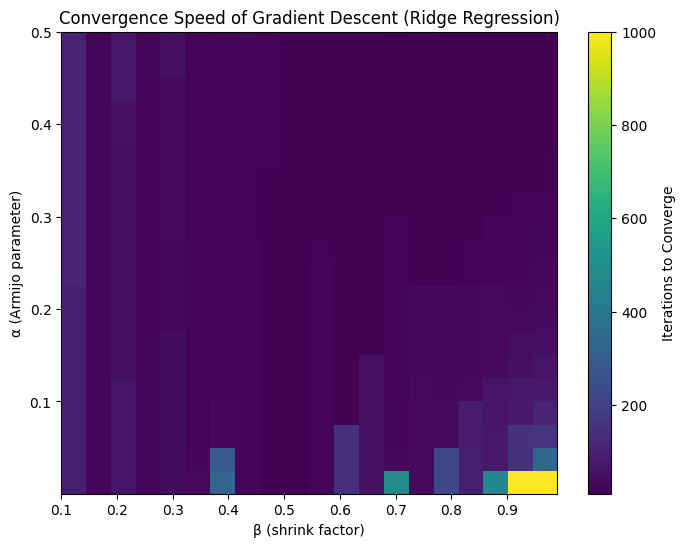

In [131]:
plt.figure(figsize=(8,6))
plt.imshow(heatmap, origin='lower', 
           extent=[beta_vals[0], beta_vals[-1],
                   alpha_vals[0], alpha_vals[-1]],
           aspect='auto')
plt.colorbar(label='Iterations to Converge')
plt.xlabel('β (shrink factor)')
plt.ylabel('α (Armijo parameter)')
plt.title('Convergence Speed of Gradient Descent (Ridge Regression)')
plt.show()

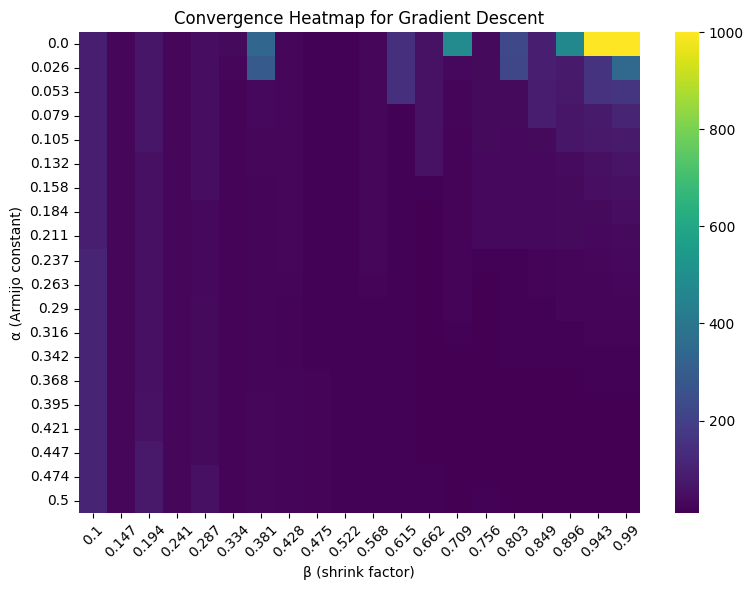

In [135]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    heatmap,
    xticklabels=np.round(beta_vals, 3),
    yticklabels=np.round(alpha_vals, 3),
    cmap="viridis"
)

plt.xlabel("β (shrink factor)")
plt.ylabel("α (Armijo constant)")
plt.title("Convergence Heatmap for Gradient Descent")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

α=0.9, β=0.9, final objective=386.0581
α=0.9, β=0.5, final objective=448.0272
α=0.9, β=0.1, final objective=494.4159
α=0.9, β=0.01, final objective=552.8463
α=0.5, β=0.9, final objective=379.9709
α=0.5, β=0.5, final objective=464.8510
α=0.5, β=0.1, final objective=494.1746
α=0.5, β=0.01, final objective=585.0951
α=0.1, β=0.9, final objective=485.3590
α=0.1, β=0.5, final objective=467.1852
α=0.1, β=0.1, final objective=494.1746
α=0.1, β=0.01, final objective=585.0951
α=0.01, β=0.9, final objective=485.6265
α=0.01, β=0.5, final objective=472.0334
α=0.01, β=0.1, final objective=494.1746
α=0.01, β=0.01, final objective=585.0951


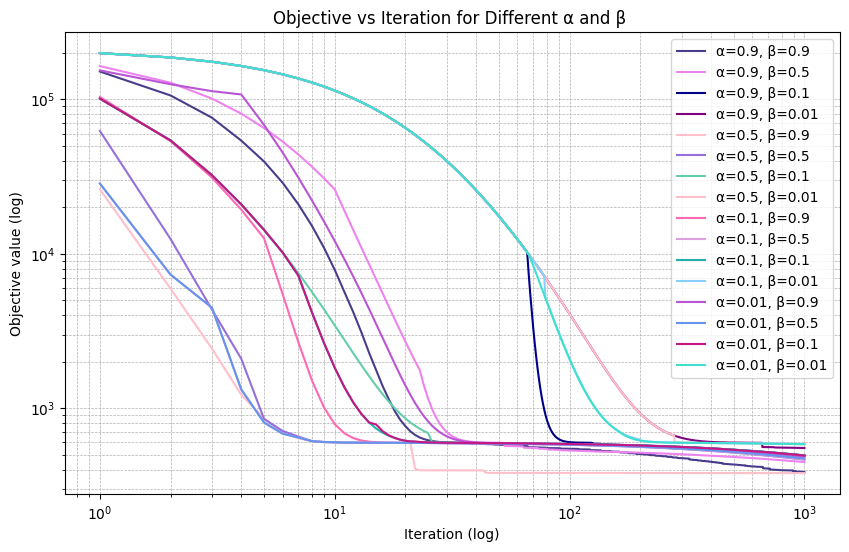

In [ ]:

lam = 1.0   # regularization strength
s = 1.0     # initial step size

alpha_values = [0.9, 0.5, 0.1, 0.01]
beta_values = [0.9, 0.5, 0.1, 0.01]
colors = ["darkslateblue", "violet", "darkblue", "purple", "pink", "mediumpurple", "mediumaquamarine", "pink", 'hotpink', 'plum', 
          'lightseagreen', 'lightskyblue', 'mediumorchid', 'cornflowerblue', 'mediumvioletred', 'turquoise']


results = {}

for alpha in alpha_values:
    for beta in beta_values:
        w_gd, obj_values = gradient_descent(X_train, y_train, lam, s, alpha, beta)
        results[(alpha, beta)] = obj_values
        print(f"α={alpha}, β={beta}, final objective={obj_values[-1]:.4f}")

# --- Plot ---
plt.figure(figsize=(10,6))

for i, ((alpha, beta), obj_values) in enumerate(results.items()):
    label = f"α={alpha}, β={beta}"
    iterations = np.arange(1, len(obj_values) + 1)
    plt.plot(iterations, obj_values, label=label, color=colors[i])



plt.xscale('log')   # <-- Logarithmic x-axis (iterations)
plt.yscale('log')   # <-- Logarithmic y-axis (objective values)
plt.xlabel('Iteration (log)')
plt.ylabel('Objective value (log)')
plt.title('Objective vs Iteration for Different α and β ')
plt.legend()
plt.grid(True, which="both", ls="--", linewidth=0.5)

downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "plot1.png")
plt.savefig(downloads_path, dpi=1200)

plt.show()

In [138]:
# Gradient descent with Armijo line search and convergence criterion
def gradient_descent(X, y, lam, s, alpha, beta, tol=1e-6, max_iter=1000):
    w = np.zeros(X.shape[1])
    obj_values = []

    for iteration in range(1, max_iter + 1):
        grad = ridge_grad(X, y, w, lam)
        t = s
        # Armijo condition
        while ridge_objective(X, y, w - t*grad, lam) > ridge_objective(X, y, w, lam) - alpha * t * np.dot(grad, grad):
            t *= beta  # shrink step size
        w_new = w - t * grad
        obj_values.append(ridge_objective(X, y, w_new, lam))
        
        # Check convergence
        if np.linalg.norm(w_new - w) < tol:
            w = w_new
            break
        w = w_new

    return w, obj_values, iteration

# Parameters
lam = 1.0
s = 1.0
alpha_values = [0.9, 0.5, 0.1, 0.01]
beta_values = [0.9, 0.5, 0.1, 0.01]

results = {}

for alpha in alpha_values:
    for beta in beta_values:
        w_gd, obj_values, iters = gradient_descent(X_train, y_train, lam, s, alpha, beta)
        results[(alpha, beta)] = (obj_values, iters)
        print(f"α={alpha}, β={beta}, final objective={obj_values[-1]:.4f}, iterations={iters}")

α=0.9, β=0.9, final objective=386.0581, iterations=1000
α=0.9, β=0.5, final objective=448.0272, iterations=1000
α=0.9, β=0.1, final objective=494.4159, iterations=1000
α=0.9, β=0.01, final objective=552.8463, iterations=1000
α=0.5, β=0.9, final objective=379.9709, iterations=1000
α=0.5, β=0.5, final objective=464.8510, iterations=1000
α=0.5, β=0.1, final objective=494.1746, iterations=1000
α=0.5, β=0.01, final objective=585.0951, iterations=1000
α=0.1, β=0.9, final objective=485.3590, iterations=1000
α=0.1, β=0.5, final objective=467.1852, iterations=1000
α=0.1, β=0.1, final objective=494.1746, iterations=1000
α=0.1, β=0.01, final objective=585.0951, iterations=1000
α=0.01, β=0.9, final objective=485.6265, iterations=1000
α=0.01, β=0.5, final objective=472.0334, iterations=1000
α=0.01, β=0.1, final objective=494.1746, iterations=1000
α=0.01, β=0.01, final objective=585.0951, iterations=1000


In [159]:
# Gradient descent with Armijo line search and convergence criterion
def gradient_descent(X, y, lam, s, alpha, beta, tol=1e-6, max_iter=1000):
    w = np.zeros(X.shape[1])
    obj_values = []

    for iteration in range(1, max_iter + 1):
        grad = ridge_grad(X, y, w, lam)
        t = s
        # Armijo condition
        while ridge_objective(X, y, w - t*grad, lam) > ridge_objective(X, y, w, lam) - alpha * t * np.dot(grad, grad):
            t *= beta  # shrink step size
        w_new = w - t * grad
        obj_values.append(ridge_objective(X, y, w_new, lam))
        
        # Check convergence
        if np.linalg.norm(w_new - w) < tol:
            w = w_new
            break
        w = w_new

    return w, obj_values, iteration

# Parameters
lam = 1.0
s = 1.0
alpha_values = [0.9, 0.8, 0.7, 0.6, 0.5]
beta_values = [0.9, 0.8, 0.7, 0.6, 0.5]


# Store results
results = []

for alpha in alpha_values:
    for beta in beta_values:
        w_gd, obj_values, iters = gradient_descent(X_train, y_train, lam, s, alpha, beta)
        final_obj = obj_values[-1]
        results.append({
            "alpha": alpha,
            "beta": beta,
            "final_objective": final_obj,
            "iterations": iters
        })

# Convert to DataFrame for easier visualization
df_results = pd.DataFrame(results)
print("Results Table:")
print(df_results)



Results Table:
    alpha  beta  final_objective  iterations
0     0.9   0.9       386.058050        1000
1     0.9   0.8       380.497114        1000
2     0.9   0.7       455.574900        1000
3     0.9   0.6       413.408941        1000
4     0.9   0.5       448.027233        1000
5     0.8   0.9       379.976163        1000
6     0.8   0.8       381.567354        1000
7     0.8   0.7       399.315041        1000
8     0.8   0.6       414.091260        1000
9     0.8   0.5       451.360600        1000
10    0.7   0.9       380.535978        1000
11    0.7   0.8       380.027321        1000
12    0.7   0.7       381.664358        1000
13    0.7   0.6       422.791431        1000
14    0.7   0.5       464.902066        1000
15    0.6   0.9       379.962833         984
16    0.6   0.8       381.952535        1000
17    0.6   0.7       386.640972        1000
18    0.6   0.6       425.951789        1000
19    0.6   0.5       464.923786        1000
20    0.5   0.9       379.970885        

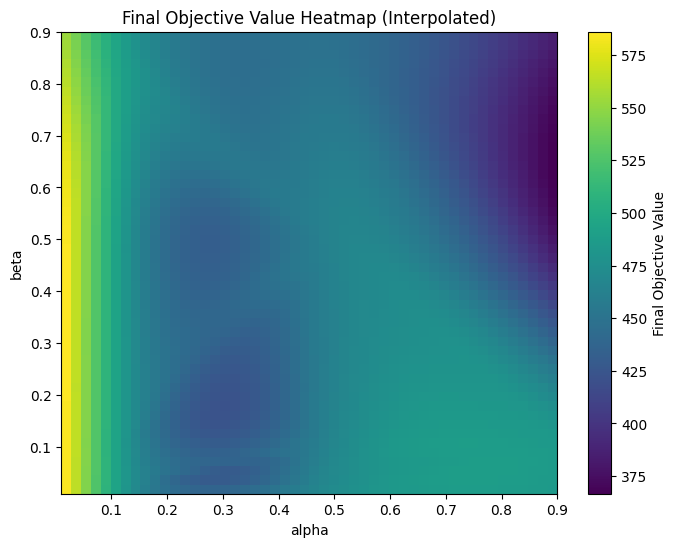

In [ ]:
alpha_vals = df_results['alpha'].values
beta_vals = df_results['beta'].values
obj_vals = df_results['final_objective'].values

# Create finer grid
alpha_lin = np.linspace(alpha_vals.min(), alpha_vals.max(), 50)
beta_lin = np.linspace(beta_vals.min(), beta_vals.max(), 50)
alpha_grid, beta_grid = np.meshgrid(alpha_lin, beta_lin)

# Interpolate objective values on finer grid
obj_grid = griddata(
    points=(alpha_vals, beta_vals),
    values=obj_vals,
    xi=(alpha_grid, beta_grid),
    method='cubic'
)

plt.figure(figsize=(8, 6))
# Plot heatmap using imshow
plt.imshow(obj_grid.T, origin='lower', 
           extent=[alpha_lin.min(), alpha_lin.max(), beta_lin.min(), beta_lin.max()],
           aspect='auto', cmap='viridis')
plt.colorbar(label='Final Objective Value')
plt.xlabel('Alpha')
plt.ylabel('Aeta')
plt.title('Final Objective Value Heatmap (Interpolated)')
plt.show()

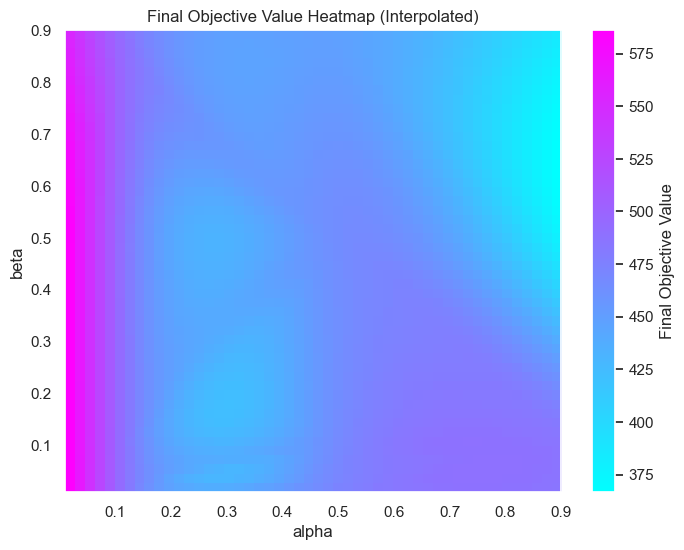

In [153]:
# Original alpha, beta, final objective values
alpha_vals = df_results['alpha'].values
beta_vals = df_results['beta'].values
obj_vals = df_results['final_objective'].values

# Create a finer grid for interpolation
alpha_lin = np.linspace(alpha_vals.min(), alpha_vals.max(), 50)
beta_lin = np.linspace(beta_vals.min(), beta_vals.max(), 50)
alpha_grid, beta_grid = np.meshgrid(alpha_lin, beta_lin)

# Interpolate final objective values on the finer grid
obj_grid = griddata(
    points=(alpha_vals, beta_vals),
    values=obj_vals,
    xi=(alpha_grid, beta_grid),
    method='cubic'
)

# Plot smooth heatmap
plt.figure(figsize=(8, 6))
sns.set_theme()  # Seaborn styling

plt.imshow(
    obj_grid.T, origin='lower',
    extent=[alpha_lin.min(), alpha_lin.max(), beta_lin.min(), beta_lin.max()],
    aspect='auto',
    cmap='cool'
)

plt.colorbar(label='Final Objective Value')
plt.xlabel('alpha')
plt.ylabel('beta')
plt.title('Final Objective Value Heatmap (Interpolated)')
plt.grid(False)  # remove any grid lines
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "final_value_heatmap.png")
plt.savefig(downloads_path, dpi=1200)
plt.show()

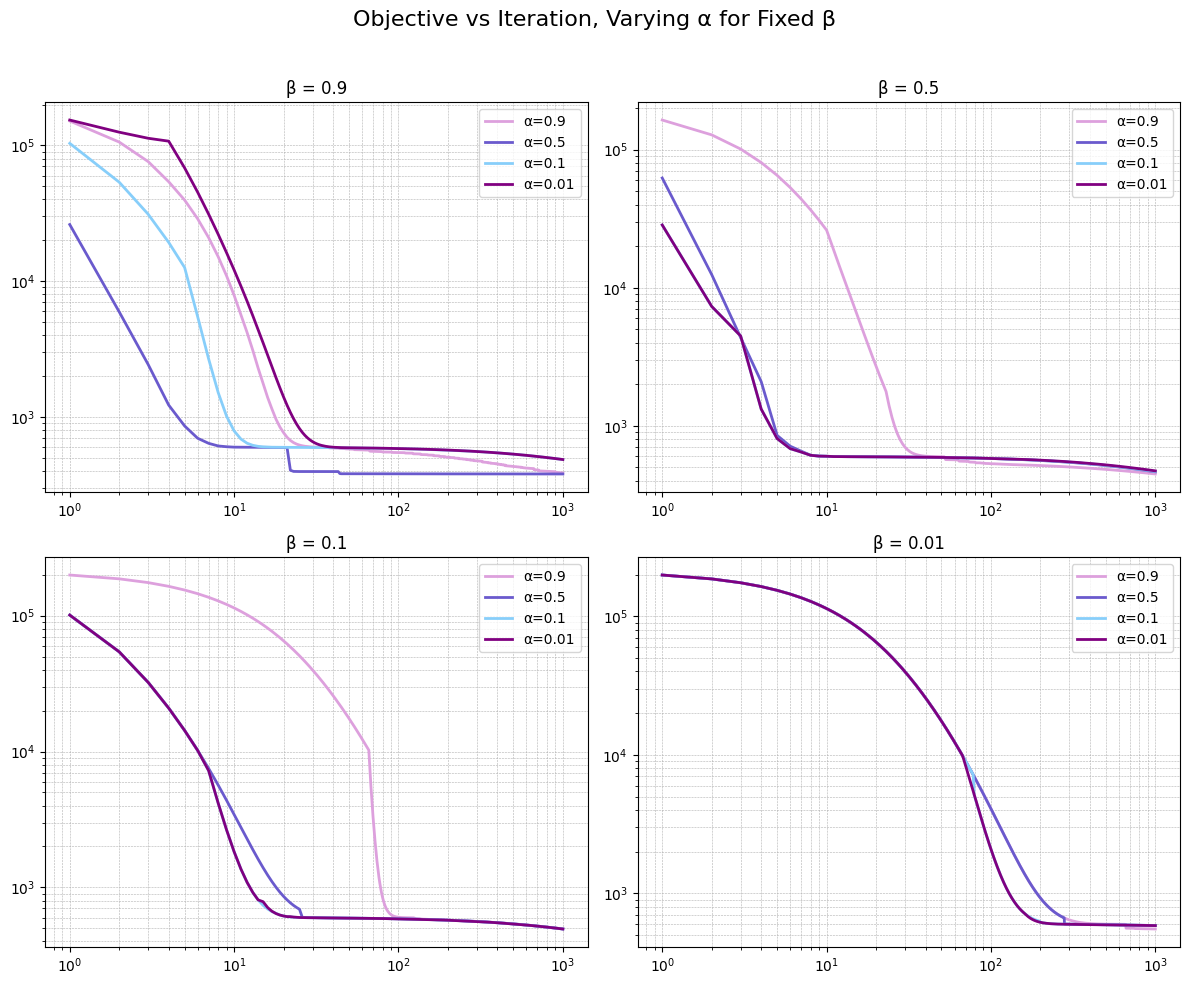

In [113]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()   # flatten so we can index 0–3

colors = ["plum", "slateblue", "lightskyblue", "purple"]   # change these to any colors you like

for i, beta in enumerate(beta_values):
    ax = axes[i]

    for idx, alpha in enumerate(alpha_values):
        iterations = np.arange(1, len(results[(alpha, beta)]) + 1)
        obj_values = results[(alpha, beta)]

        ax.plot(iterations, obj_values,
                label=f"α={alpha}",
                color=colors[idx],
                linewidth=2)

    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f"β = {beta}")
    ax.grid(True, which='both', ls='--', lw=0.4)
    ax.legend()

fig.suptitle("Objective vs Iteration, Varying α for Fixed β", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "vary_a_fixed_b.png")

plt.savefig(downloads_path, dpi=1200)
plt.show()





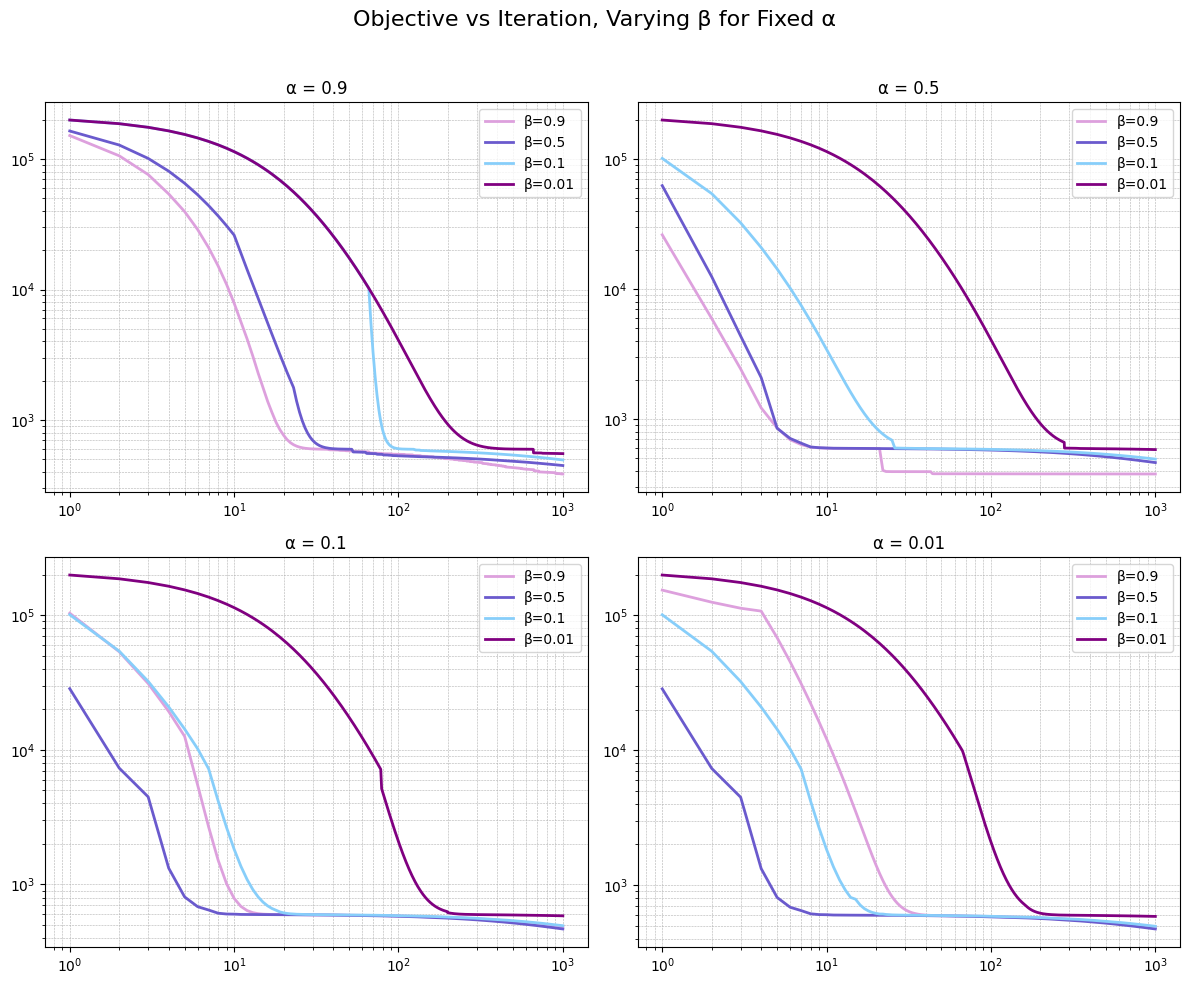

In [104]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
colors = ["plum", "slateblue", "lightskyblue", "purple"]

# Flatten axes into a simple list: [ax00, ax01, ax10, ax11]
axes = axes.flatten()

for i, alpha in enumerate(alpha_values):
    ax = axes[i]

    for idx, beta in enumerate(beta_values):
        iterations = np.arange(1, len(results[(alpha, beta)]) + 1)
        obj_values = results[(alpha, beta)]

        ax.plot(iterations, obj_values,
                label=f"β={beta}",
                color=colors[idx % len(colors)],
                linewidth=2)
 
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_title(f"α = {alpha}")
    ax.grid(True, which='both', ls='--', lw=0.4)
    ax.legend()

fig.suptitle("Objective vs Iteration, Varying β for Fixed α", fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.96])

downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "plot3.png")
plt.savefig(downloads_path, dpi=1200)
plt.show()

In [ ]:
username = os.getlogin()
print(username)

In [114]:
def gradient_descent_with_norms(X, y, lam, s, alpha, beta, max_iters=1000):
    w = np.zeros(X.shape[1])
    obj_values = []
    grad_norms = []
    step_sizes = []

    for _ in range(max_iters):
        grad = ridge_grad(X, y, w, lam)
        grad_norms.append(np.linalg.norm(grad))

        t = s  # initial step size

        # Armijo backtracking line search
        while ridge_objective(X, y, w - t * grad, lam) > ridge_objective(X, y, w, lam) - alpha * t * np.dot(grad, grad):
            t *= beta  # shrink step size

        w = w - t * grad  # update
        step_sizes.append(t)
        obj_values.append(ridge_objective(X, y, w, lam))

    return w, obj_values, grad_norms, step_sizes

s_values = [1.0, 0.5, 0.1]
alpha_values = [0.5, 0.1]
beta_values  = [0.5, 0.1]

results = {}

for s in s_values:
    for a in alpha_values:
        for b in beta_values:
            w, objs, norms, steps = gradient_descent_with_norms(
                X_train, y_train, lam=1.0, s=s, alpha=a, beta=b
            )
            results[(s, a, b)] = (objs, norms, steps)

convergence comparison for alpha beta
distance between estimated and true coefficients vs lambda
mse vs lambda
parameter norm evolution

discuss overfitting
convergebce speed heatmap
rate of convergence for alpha and beta
convergebce results
norm of the gradient
objective for convergence, not independent conepts, understand the assumptions of these theorems
positive alpha in exercise question 1 vs used negative alpha
convergence of backtracking heatmap
estimate error vs lambda around 0.7 provides smallest error

early stage convergence of j(w)


In [119]:

def ridge_closed_form(X, y, lam):
    n_features = X.shape[1]
    I = np.eye(n_features)
    w = np.linalg.inv(X.T @ X + lam * I) @ X.T @ y
    return w

def ridge_objective(X, y, w, lam):
    residual = X @ w - y
    return np.dot(residual, residual) + lam * np.dot(w, w)

def ridge_grad(X, y, w, lam):
    return 2 * (X.T @ (X @ w - y) + lam * w)

def gradient_descent_full_trace(X, y, lam, s, alpha, beta, max_iter=300):
    w = np.zeros(X.shape[1])
    norms = []

    for _ in range(max_iter):
        grad = ridge_grad(X, y, w, lam)
        t = s

        # Armijo backtracking
        f_cur = ridge_objective(X, y, w, lam)
        while ridge_objective(X, y, w - t * grad, lam) > f_cur - alpha * t * np.dot(grad, grad):
            t *= beta
            if t < 1e-20:
                break

        w = w - t * grad
        norms.append(np.linalg.norm(w))

    return np.array(norms)

# ----------------------------
#   Generate the plot
# ----------------------------

lambdas = [0.01, 0.1, 1, 10, 100, 1000]
alpha_beta_list = [
    (1e-3, 0.8),
    (1e-3, 0.5),
    (1e-2, 0.8),
    (1e-2, 0.5),
]

s = 1.0
max_iter = 300



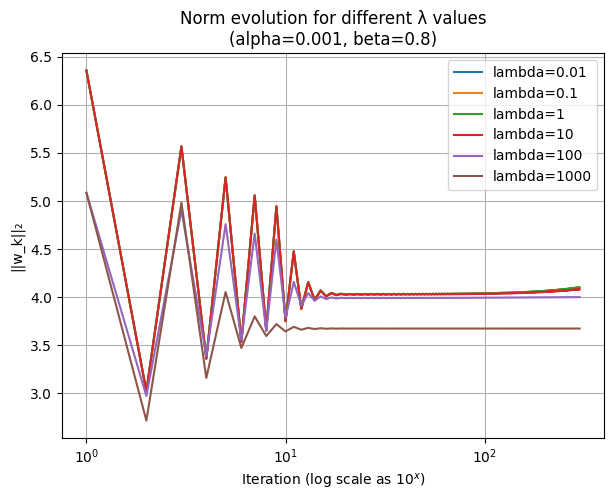

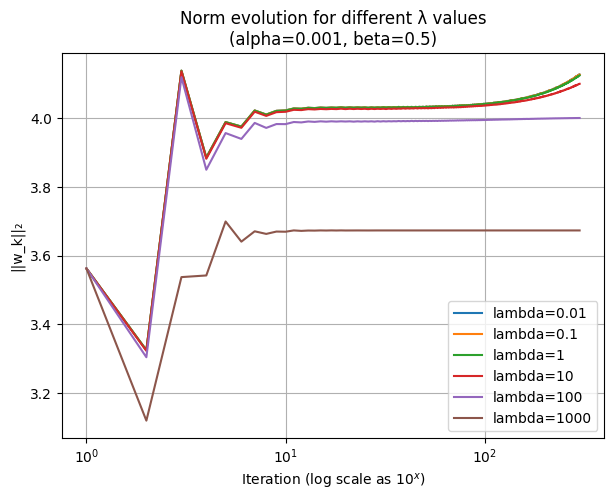

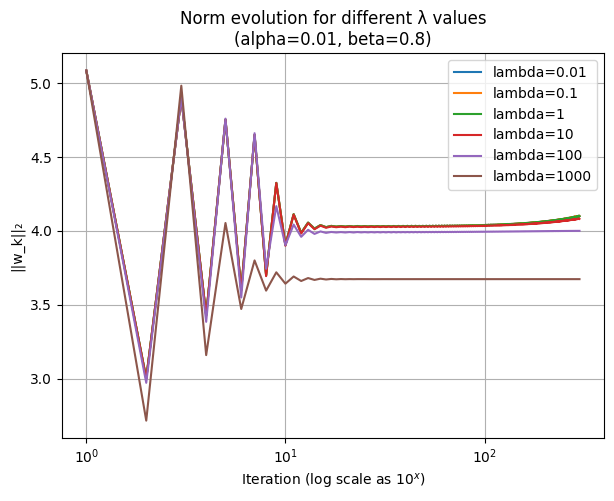

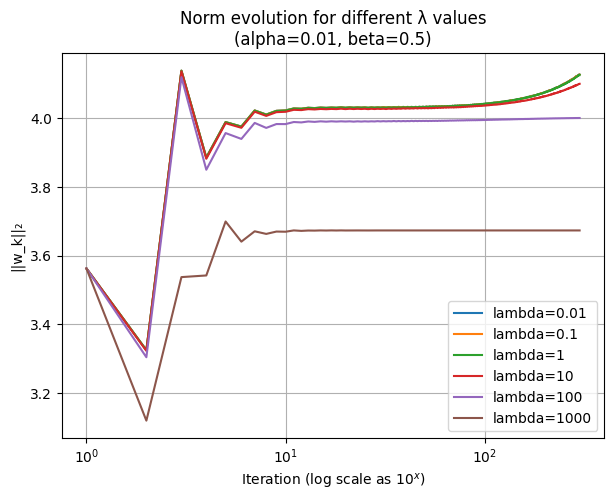

In [118]:
# Custom tick formatter that prints 10^x
def log_tick_formatter(val, pos=None):
    return r"$10^{%.0f}$" % val

for alpha, beta in alpha_beta_list:
    plt.figure(figsize=(7,5))

    for lam in lambdas:
        norms = gradient_descent_full_trace(X_train, y_train, lam, s, alpha, beta, max_iter=max_iter)
        iters = np.arange(1, len(norms)+1)

        # Plot log10(iterations)
        plt.plot(np.log10(iters), norms, label=f"lambda={lam}")

    plt.xlabel("Iteration (log scale as $10^x$)")
    plt.ylabel("||w_k||₂")
    plt.title(f"Norm evolution for different λ values\n(alpha={alpha}, beta={beta})")
    plt.legend()
    plt.grid(True)

    # Use ticks that display 10^0, 10^1, ..., 10^x
    ax = plt.gca()
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))  # integer ticks: 0,1,2,...
    ax.xaxis.set_major_formatter(log_tick_formatter)

    plt.show()

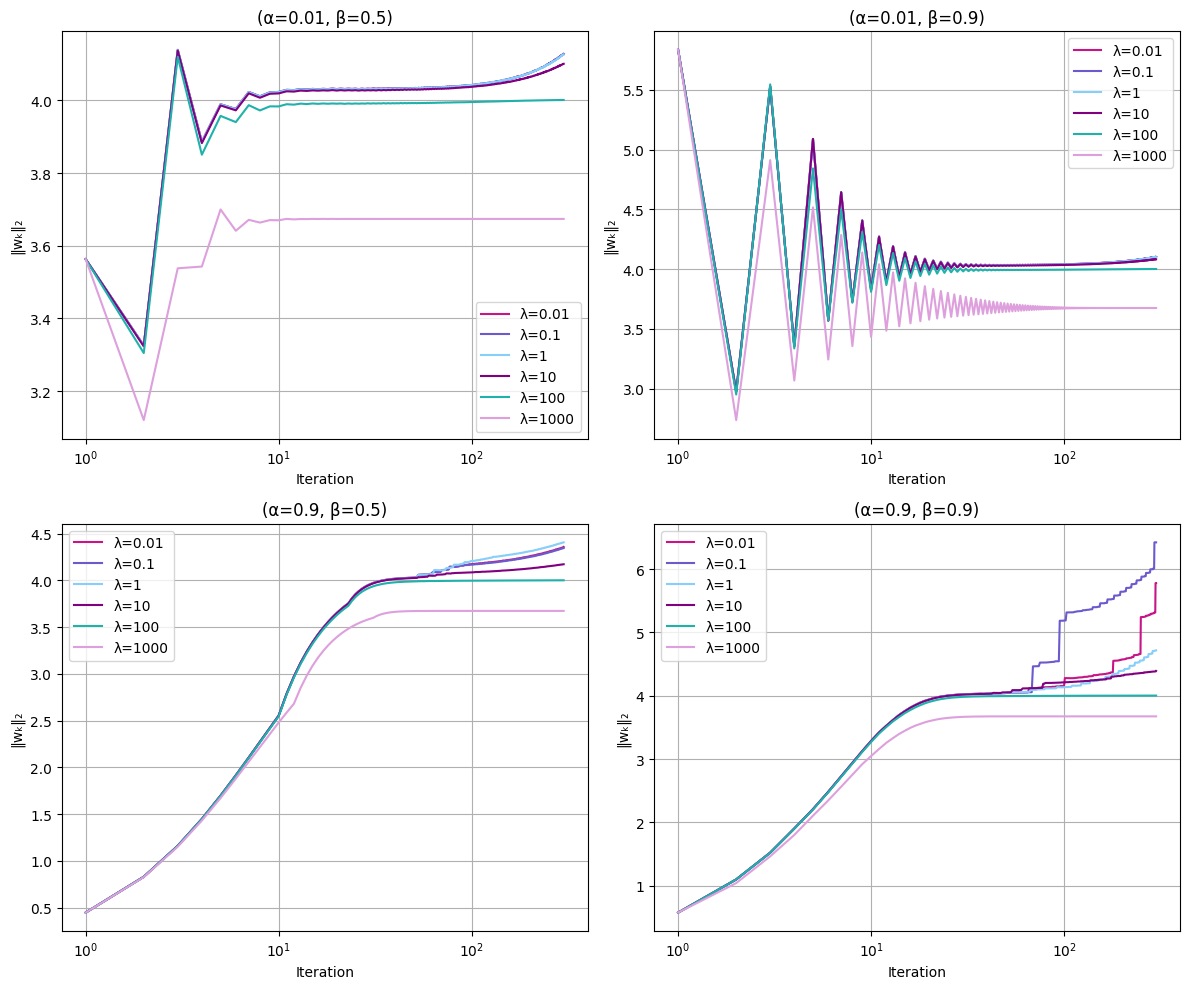

In [127]:
def log_tick_formatter(val, pos=None):
    return r"$10^{%.0f}$" % val

# ---- choose 4 (alpha, beta) pairs ----
alpha_beta_list = [
    (0.01, 0.5),
    (0.01, 0.9),
    (0.9, 0.5),
    (0.9, 0.9),
]

lambdas = [0.01, 0.1, 1, 10, 100, 1000]
s = 1.0
max_iter = 300

# ---- create a 2×2 figure ----
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()   # flatten so we can index axes[0], axes[1], ...


colors = ["mediumvioletred", "slateblue", "lightskyblue", "purple", "lightseagreen", "plum"]   

for i, (alpha, beta) in enumerate(alpha_beta_list):
    ax = axes[i]
    
    for j, lam in enumerate(lambdas):
        norms = gradient_descent_full_trace(X_train, y_train, lam, s, alpha, beta, max_iter=max_iter)
        iters = np.arange(1, len(norms) + 1)

        if colors is None:
            ax.plot(np.log10(iters), norms, label=f"λ={lam}")
        else:
            ax.plot(np.log10(iters), norms, color=colors[j], label=f"λ={lam}")

    ax.set_title(f"(α={alpha}, β={beta})")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("‖wₖ‖₂")
    ax.grid(True)

    # Format ticks as 10^x
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.xaxis.set_major_formatter(log_tick_formatter)

    ax.legend()

plt.tight_layout()
downloads_path = os.path.join(os.path.expanduser("~"), "Downloads", "vary_lambda.png")
plt.savefig(downloads_path, dpi=1200)
plt.show()